# Import thư viện

In [ ]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler    # cho mô hình ML

# GET DATA FROM YAHOO

In [ ]:
# # Tải dữ liệu Bitcoin theo giờ (1h)
# coin_df = yf.download("FPT.VN", start="2000-01-01", end="2025-01-01")

# # Giữ lại 5 cột chính (khôFPT.VNAdj Close)
# coin_df = coin_df[['Open', 'High', 'Low', 'Close', 'Volume']].reset_index()

# # Lưu ra CSV mở được trên Excel
# coin_df.to_csv("FPT.VN.csv", index=False, encoding='utf-8-sig')

# Gắn bộ dataset vô đây

In [ ]:
df = pd.read_csv(r"D:\3_ADY201m\Code_Python\LKNCY.csv")
df

,Date,Open,High,Low,Close,Volume
0,NaN,NaN,NaN,NaN,NaN,NaN
1,5/17/2019,25.020000,25.959999,18.809999,20.379999,38937500.0
2,5/20/2019,21.020000,21.020000,18.400000,18.610001,8186600.0
3,5/21/2019,18.590000,18.740000,17.330000,17.330000,8572300.0
4,5/22/2019,17.000000,17.330000,14.700000,14.750000,19697300.0
...,...,...,...,...,...,...
1412,12/24/2024,23.320000,24.180000,23.260000,24.120001,678900.0
1413,12/26/2024,23.820000,24.120001,23.820000,24.090000,528700.0
1414,12/27/2024,24.049999,24.180000,23.980000,24.120001,660800.0
1415,12/30/2024,24.000000,24.620001,24.000000,24.620001,1502700.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1416 non-null   object 
 1   Open    1416 non-null   float64
 2   High    1416 non-null   float64
 3   Low     1416 non-null   float64
 4   Close   1416 non-null   float64
 5   Volume  1416 non-null   float64
dtypes: float64(5), object(1)
memory usage: 66.6+ KB


# Clean data ---> df_clean.csv


In [ ]:
df.isnull().sum()

Date      1
Open      1
High      1
Low       1
Close     1
Volume    1
dtype: int64

In [ ]:
# Chuyển dữ liệu số về numeric
coin_lables = df.columns
for lable in coin_lables:
  if lable != 'Date':
    df[lable] = pd.to_numeric(df[lable], errors = "coerce")

# Drop các dòng có NAN (không hợp lệ/ thiếu )
df.dropna(inplace = True)

# Chuyển cột Date về dạng datetime
df['Date'] = pd.to_datetime()

# Xóa dòng trùng lặp
df.drop_duplicates(inplace = True)

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1416 entries, 1 to 1416
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1416 non-null   datetime64[ns]
 1   Open    1416 non-null   float64       
 2   High    1416 non-null   float64       
 3   Low     1416 non-null   float64       
 4   Close   1416 non-null   float64       
 5   Volume  1416 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 77.4 KB


In [ ]:
print('Số giá trị bị NAN : ', df.isnull().sum().sum())

Số giá trị bị NAN :  0


In [ ]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,1416,1416.000000,1416.000000,1416.000000,1416.000000,1.416000e+03
mean,2022-03-08 23:58:58.983050752,17.935429,18.493376,17.378725,17.916547,5.119024e+06
min,2019-05-17 00:00:00,0.980000,1.660000,0.950000,1.380000,0.000000e+00
25%,2020-10-11 06:00:00,9.677500,10.100000,9.210000,9.500000,1.141450e+06
50%,2022-03-08 12:00:00,18.835000,19.200001,18.415000,18.790001,1.913350e+06
75%,2023-08-04 18:00:00,24.000000,24.642499,23.400000,24.035000,3.547975e+06
max,2024-12-31 00:00:00,49.150002,51.380001,49.060001,50.020000,2.936013e+08
std,NaN,9.548206,9.815276,9.283191,9.556231,1.724351e+07


In [ ]:
# Kiểm tra logic OHLC 
mask_invalid  = (df['High'] < df[['Open' , 'Close' , 'Low']].max(axis = 1)) | (df['Low'] > df[['Open' , 'Close' , 'Low']].min(axis = 1))
data_issue_log  = df.loc[mask_invalid , ['Date', 'Open', 'High', 'Low', 'Close']]

data_issue_log

,Date,Open,High,Low,Close


In [ ]:
# Kiểm tra giá và khối lượng = 0 --> flag
mask_zero  = (df['Volume'] == 0) | (df[['Open', 'High', 'Low' , 'Close']] == 0).any(axis =1)
data_issue_log  = pd.concat([data_issue_log ,  df.loc[mask_zero , ['Date' , 'Open' , 'High', 'Low', 'Close','Volume']]])

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # ép kiểu
df['gap_days'] = df['Date'].diff().dt.days
missing_days = df[df['gap_days'] > 3][['Date','gap_days']]
missing_days.head()


,Date,gap_days
7,2019-05-28,4.0
75,2019-09-03,4.0
171,2020-01-21,4.0
190,2020-02-18,4.0
228,2020-04-13,4.0


Tạo file 

In [ ]:
df_clean = df.copy()
df_clean.to_csv('df_clean.csv', index = False)
data_issue_log.to_csv("data_issue_log.csv", index = False)

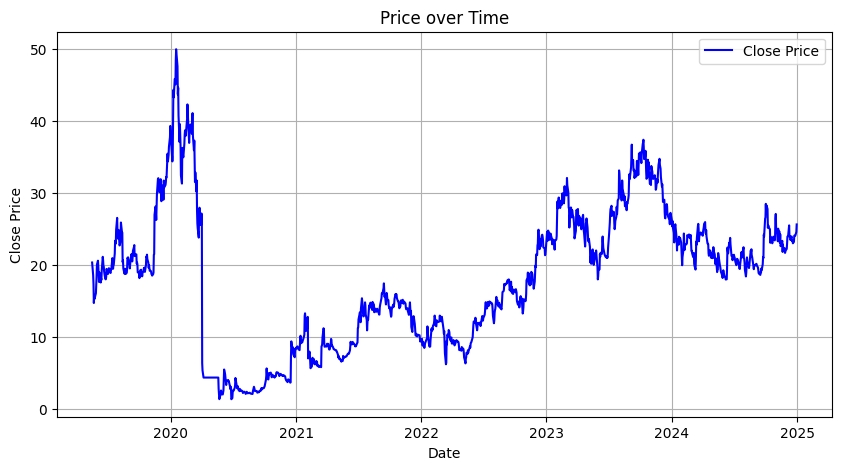

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.title('Price over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()


# Tạo thêm các feature

In [ ]:
# Đọc file df_clean 
df = pd.read_csv('df_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop= True)  

CLOSE, OPEN, HIGH, LOW, VOL = 'Close', 'Open', 'High', 'Low', 'Volume'

df['intraday_range'] = df[HIGH] - df[LOW]
df['return'] = df['return'] if 'return' in df.columns else df['Close'].pct_change()
df['volatility_120'] = df['return'].rolling(120, min_periods=120).std()


df['log_return'] = np.log(df[CLOSE] / df[CLOSE].shift(1))
df['range_pct'] = (df['High'] - df['Low']) / df['Close']     # biên độ %
df['close_open_ret'] = (df['Close'] - df['Open']) / df['Open']

# 2) các thống kê rolling (120 ngày liên tiếp )  cột  (volume , return)
win = 120
df['vol_mean'] = df['Volume'].rolling(win).mean()
df['vol_std']  = df['Volume'].rolling(win).std()
df['ret_mean'] = df['return'].rolling(win).mean()
df['ret_std']  = df['return'].rolling(win).std()

df['vol_z'] = (df['Volume'] - df['vol_mean']) / df['vol_std']
df['ret_z'] = (df['return'] - df['ret_mean']) / df['ret_std']

# 3) Tỉ lệ khối lượng so với trung bình (Volume ratio )
df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(30).mean()

# 4)  MA – Moving Average

df['MA_5']  = df['Close'].rolling(5).mean()
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

# 5) RSI (14)

delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14, min_periods=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14, min_periods=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 6) Bollinger Bands (20, 2σ)

ma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = ma20 + 2 * std20
df['BB_lower'] = ma20 - 2 * std20
df['BB_pos'] = (df['Close'] - ma20) / (2 * std20)  # vị trí giá trong dải BB

# 7) MACD (12, 26, 9)

ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD_line']   = ema12 - ema26
df['MACD_signal'] = df['MACD_line'].ewm(span=9, adjust=False).mean()
df['MACD_hist']   = df['MACD_line'] - df['MACD_signal']

# 8) ATR (14)

tr = pd.concat([
    df['High'] - df['Low'],
    (df['High'] - df['Close'].shift(1)).abs(),
    (df['Low']  - df['Close'].shift(1)).abs()
], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(14).mean()

# 9 ) Chuẩn hóa z-score

for col in ['return','vol_ratio','range_pct','RSI_14']:
    df[col + '_z'] = (df[col] - df[col].rolling(30, min_periods=20).mean()) / df[col].rolling(30, min_periods=20).std()



 Xử lý NaN & xuất file

In [ ]:
df_feat = df.dropna().reset_index(drop=True)
df_feat.to_csv('df_feat.csv', index=False)
print('Write file "df_feat" success')

Write file "df_feat" success


# Phát hiện bất thường theo các quy tắc 

1) Rule-based

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("df_feat.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# MA30 của Volume
ma30_vol = df['Volume'].rolling(30, min_periods=30).mean()


# --- 1) Luật (nhạy hơn) ---
df['flag_vol_return'] = (df['vol_ratio'] > 1.8) & (df['return'].abs() > 0.02)

# Vượt BB_upper 1% + Volume > 2 x MA30
df['flag_bollinger'] = (df['Close'] > df['BB_upper'] * 1.002) & (df['Volume'] > 1.2 * ma30_vol)

# --- 2) Z-band nhẹ tay hơn ---
abs_ret_z = df['ret_z'].abs()
vol_z = df['vol_z']

cond_high = ((abs_ret_z >= 2.0) | (vol_z >= 2.0)) 
cond_med  = ((abs_ret_z.between(1.2, 2.0, inclusive='left')) |
             (vol_z.between(1.2, 2.0, inclusive='left')) |
             (df['intraday_range'] >= 0.015))
cond_low  = ((abs_ret_z.between(0.8, 1.2, inclusive='left')) |
             (vol_z.between(0.8, 1.2, inclusive='left')))



df['z_band'] = 'None'
df.loc[cond_low,  'z_band'] = 'Low'
df.loc[cond_med,  'z_band'] = 'Medium'
df.loc[cond_high, 'z_band'] = 'High'

# # --- 3) Điểm rule_score (chuẩn hóa 0.8 → 1.8) ---
z_star = np.maximum(abs_ret_z, vol_z)
df['z_intensity'] = np.clip((z_star - 0.8) / (2.0 - 0.8), 0, 1)




# Thêm
df['flag_rsi_pump'] = (df['RSI_14'] > 70) & (df['vol_ratio'] > 1.5)
df['binary_flags'] = (
    df['flag_vol_return'].astype(int) + 
    df['flag_bollinger'].astype(int) + 
    df['flag_rsi_pump'].astype(int)
) / 3.0

# Nhấn mạnh cờ boole để tăng độ nhạy
df['rule_score'] = 0.35 * df['z_intensity'] + 0.65 * df['binary_flags']

# cho bonus lớn hơn khi có ít nhất 1 flag hoặc High z_band:
bonus = (
    0.15 * ((df['binary_flags'] > 0).astype(float)) +
    0.10 * (df['z_band'] == 'High'))

df['rule_score'] = np.clip(df['rule_score'] + bonus, 0, 1)

cols_keep = [
    'Date','return','vol_ratio','ret_z','vol_z','intraday_range','close_open_ret',
    'flag_vol_return','flag_bollinger','z_band','z_intensity','binary_flags','rule_score'
]
df_rule = df[cols_keep].copy()
df_rule.to_csv("df_rule.csv", index=False)

print("Stage 3 (nhạy hơn) ✅  -> df_rule.csv")
print(df_rule.tail(3))



Stage 3 (nhạy hơn) ✅  -> df_rule.csv
           Date    return  vol_ratio     ret_z     vol_z  intraday_range  \
1257 2024-12-27  0.001245   0.464741 -0.023557 -0.716056        0.200001   
1258 2024-12-30  0.020730   1.053262  0.494446 -0.226316        0.620001   
1259 2024-12-31  0.042648   1.037819  1.059807 -0.215893        1.699999   

      close_open_ret  flag_vol_return  flag_bollinger  z_band  z_intensity  \
1257        0.002911            False           False  Medium     0.000000   
1258        0.025833            False           False  Medium     0.000000   
1259        0.031338            False           False  Medium     0.216505   

      binary_flags  rule_score  
1257           0.0    0.000000  
1258           0.0    0.000000  
1259           0.0    0.075777  


PHÁT HIỆN BẤT THƯỜNG BẰNG ML (UNSUPERVISED)

In [ ]:
# --- 1. Load dữ liệu đặc trưng ---
df = pd.read_csv("df_feat.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# --- 2. Chọn các biến đưa vào mô hình ---
features = [
    'log_return', 'vol_ratio', 'range_pct', 'RSI_14',
    'ret_z', 'vol_z', 'volatility_120', 'MACD_hist', 'BB_pos', 'ATR_14'
]

# --- 3. Chuẩn hoá dữ liệu đầu vào ---
X = df[features]
mask = X.notna().all(axis=1)
X_scaled = np.full((len(df), len(features)), np.nan)
X_scaled[mask] = StandardScaler().fit_transform(X[mask])


# --- 3. Huấn luyện mô hình IsolationForest ---
iso = IsolationForest(
    n_estimators=500,
    contamination=0.01,                                            # tỉ lệ dự kiến điểm bất thường
    random_state=42
)

iso.fit(X_scaled)

# --- 4. Tính điểm bất thường (ml_score) ---
# decision_function: càng lớn = càng bình thường → đảo dấu & chuẩn hoá về [0,1]
raw = -iso.decision_function(X_scaled).reshape(-1, 1)
scaler = MinMaxScaler()
df['ml_score'] = scaler.fit_transform(raw)

# --- 5. Xuất kết quả ---
df.to_csv("df_ml.csv", index=False)
print(" Đã tạo cột ml_score trong df_ml.csv")
print(df[['Date', 'ml_score']].tail(10))

 Đã tạo cột ml_score trong df_ml.csv
           Date  ml_score
1250 2024-12-17  0.022956
1251 2024-12-18  0.064868
1252 2024-12-19  0.046766
1253 2024-12-20  0.055243
1254 2024-12-23  0.022246
1255 2024-12-24  0.053935
1256 2024-12-26  0.059590
1257 2024-12-27  0.062814
1258 2024-12-30  0.063649
1259 2024-12-31  0.127481


# Ensemble & Gán nhãn

In [ ]:
import numpy as np
import pandas as pd

# --- 1. Load dữ liệu ---
df_rule = pd.read_csv("df_rule.csv")
df_ml   = pd.read_csv("df_ml.csv")

# Gộp theo Date (tránh lỗi lệch chỉ số)
df_final = pd.merge(df_ml, df_rule[['Date', 'rule_score']], on='Date', how='left')

# --- 2. Ensemble score ---
df_final['anomaly_score'] = 0.4 * df_final['ml_score'] + 0.6 * df_final['rule_score']

# --- 3. Label Yes/No ---
THRESHOLD = 0.4  # có thể điều chỉnh lên 0.45–0.5 nếu cần giảm cảnh báo
df_final['label'] = np.where(df_final['anomaly_score'] >= THRESHOLD, 'Yes', 'No')

# --- 4. Severity ---
def classify_severity(row):
    abs_ret_z = abs(row.get('ret_z', 0))
    vol_z = row.get('vol_z', 0)
    score = row['anomaly_score']

    if (abs_ret_z >= 3) or (vol_z >= 3) or (score >= 0.75):
        return 'High'
    elif (0.55 <= score < 0.75) or (2 <= abs_ret_z < 3) or (2 <= vol_z < 3):
        return 'Medium'
    elif (THRESHOLD <= score < 0.55) or (1.5 <= abs_ret_z < 2) or (1.5 <= vol_z < 2):
        return 'Low'
    else:
        return 'Normal'

df_final['severity'] = df_final.apply(classify_severity, axis=1)

# --- 5. Xuất kết quả cuối ---
cols_export = ['Date', 'anomaly_score', 'label', 'severity']
df_final.to_csv("df_final_output.csv", index=False)

print("Stage 5 (Ensemble Final)  -> df_final_output.csv")
print(f"Tổng số dòng: {len(df_final)} | Số phiên Yes: {(df_final['label']=='Yes').sum()} | Tỷ lệ: {(df_final['label']=='Yes').mean()*100:.2f}%")
print(df_final[cols_export].tail(10))


Stage 5 (Ensemble Final)  -> df_final_output.csv
Tổng số dòng: 1260 | Số phiên Yes: 143 | Tỷ lệ: 11.35%
            Date  anomaly_score label severity
1250  2024-12-17       0.009182    No   Normal
1251  2024-12-18       0.025947    No   Normal
1252  2024-12-19       0.018707    No   Normal
1253  2024-12-20       0.022097    No   Normal
1254  2024-12-23       0.008898    No   Normal
1255  2024-12-24       0.044957    No   Normal
1256  2024-12-26       0.023836    No   Normal
1257  2024-12-27       0.025125    No   Normal
1258  2024-12-30       0.025460    No   Normal
1259  2024-12-31       0.096459    No   Normal


# Gom cụm bất thường & pump-dump

In [ ]:

# --- 1) Load dữ liệu ---
final = pd.read_csv("df_final_output.csv")   
feat  = pd.read_csv("df_feat.csv")           

# Đảm bảo Date chuẩn datetime
final['Date'] = pd.to_datetime(final['Date'])
feat['Date']  = pd.to_datetime(feat['Date'])

# Nếu file final không có Close thì merge thêm từ feat
if 'Close' not in final.columns:
    final = pd.merge(final, feat[['Date', 'Close', 'return', 'ret_z', 'vol_z']], on='Date', how='left')
else:
    # Merge thêm các cột còn thiếu (ret_z, vol_z, return)
    if 'ret_z' not in final.columns or 'vol_z' not in final.columns:
        final = pd.merge(final, feat[['Date', 'return', 'ret_z', 'vol_z']], on='Date', how='left')

# --- 2) Tính post_1d / 3d / 5d ---
for n in (1, 3, 5):
    final[f'Close_f{n}'] = final['Close'].shift(-n)
    final[f'post_{n}d']  = (final[f'Close_f{n}'] / final['Close'] - 1.0) * 100.0

# ------ 3) Tạo cluster cho label = "Yes" (gap ≤ 2 ngày) ---
yes = final[final['label'] == 'Yes'].copy()
yes['diff_days'] = yes['Date'].diff().dt.days
yes['new_cluster'] = (yes['diff_days'].isna()) | (yes['diff_days'] > 2)
yes['cluster_id'] = yes['new_cluster'].cumsum()

clusters = []
for cid, block in yes.groupby('cluster_id'):
    start_date = block['Date'].iloc[0]
    end_date   = block['Date'].iloc[-1]
    length_days = (end_date - start_date).days + 1

    n_high_days = (block['severity'] == 'High').sum()
    max_vol_z = block['vol_z'].max()
    avg_ret = block['return'].mean() * 100

    # post_xd từ END
    end_idx = block.index[-1]
    post_1d = final.loc[end_idx, 'post_1d']
    post_3d = final.loc[end_idx, 'post_3d']
    post_5d = final.loc[end_idx, 'post_5d']

    # --- 4) Pump–Dump check ---
    pump_dump = 0
    pump_pct = dump_pct = time_to_peak = time_to_dump = np.nan

    # Chỉ kiểm tra nếu trong cụm có vol_z ≥ 2
    if (block['vol_z'] >= 2).any():
        
        peak_pos = block['Close'].values.argmax()
        peak_close = block['Close'].iloc[peak_pos]
        start_close = block['Close'].iloc[0]
        peak_idx = block.index[peak_pos]

        start_close = block['Close'].iloc[0]

        pump_pct = (peak_close / start_close - 1) * 100
        time_to_peak = (block.loc[block['Close'].idxmax(), 'Date'] - start_date).days

        # Tìm dump trong 3 ngày sau peak
        look = final.iloc[peak_idx + 1 : peak_idx + 4].copy()
        if not look.empty:
            min_close = look['Close'].min()
            dump_pct = (min_close / peak_close - 1) * 100
            time_to_dump = (look.loc[look['Close'].idxmin(), 'Date'] - block.loc[peak_idx, 'Date']).days
            if dump_pct <= -5:
                pump_dump = 1

    clusters.append({
        'cluster_id': cid,
        'start_date': start_date.date(),
        'end_date': end_date.date(),
        'length_days': length_days,
        'n_high_days': n_high_days,
        'max_vol_z': max_vol_z,
        'avg_ret_%': avg_ret,
        'post_1d_%': post_1d,
        'post_3d_%': post_3d,
        'post_5d_%': post_5d,
        'pump_dump': pump_dump,
        'pump_pct_%': pump_pct,
        'dump_pct_%': dump_pct,
        'time_to_peak_days': time_to_peak,
        'time_to_dump_days': time_to_dump
    })

# --- 5) Xuất kết quả ---
clusters_df = pd.DataFrame(clusters)
clusters_df.to_csv("clusters.csv", index=False)

print("File clusters.csv đã được tạo thành công.")
print(clusters_df.head())


File clusters.csv đã được tạo thành công.
   cluster_id  start_date    end_date  length_days  n_high_days  max_vol_z  \
0           1  2019-11-13  2019-11-15            3            2   6.586924   
1           2  2019-11-18  2019-11-22            5            3   5.801258   
2           3  2019-11-25  2019-11-26            2            1   2.021268   
3           4  2019-12-23  2019-12-23            1            0   2.124353   
4           5  2019-12-27  2019-12-27            1            0   1.721191   

   avg_ret_%  post_1d_%  post_3d_%  post_5d_%  pump_dump  pump_pct_%  \
0  19.253710   4.219095  -2.664697  10.473723          0   25.908675   
1   2.114610   7.202679   5.427132   1.306531          0    6.001422   
2   3.757587  -1.962614  -5.794389  -7.040494          1    0.312495   
3  10.282701  -3.042259   2.647883  10.873241          0    0.000000   
4   3.171005   3.677278   4.500558  -5.515912          0         NaN   

   dump_pct_%  time_to_peak_days  time_to_dump_days  
0 

# Kiểm định và giảm nhiễu

In [ ]:
# === Stage 7: Validation & Noise Reduction ===
import pandas as pd
import numpy as np

# --- 1. Load dữ liệu cần thiết ---
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Kiểm tra cột cần thiết để tránh lỗi nếu merge thiếu từ stage trước
for c in ['ret_z','vol_z','label','anomaly_score']:
    if c not in df.columns:
        raise ValueError(f"Thiếu cột {c} trong df_final_output.csv – cần merge từ stage trước.")

# --- 2. SENSITIVITY TEST ---
# Thử các ngưỡng z khác nhau để xem số ngày bất thường thay đổi thế nào
sensitivity = []
for z_th in [2.0, 2.5, 3.0]:
    subset = df[(df['ret_z'].abs() >= z_th) | (df['vol_z'] >= z_th)]
    sensitivity.append({
        'z_threshold': z_th,
        'n_detected_days': len(subset),
        'ratio_detected_%': round(len(subset) / len(df) * 100, 2)
    })
sensitivity_df = pd.DataFrame(sensitivity)

# --- 3. BOOTSTRAP / PERMUTATION TEST ---
np.random.seed(42)
n = len(df)
THRESHOLD = 0.4   # đồng bộ với Stage 5
actual_detected = (df['label'] == 'Yes').sum()
simulations = []

for _ in range(2000):
    shuffled = np.random.permutation(df['anomaly_score'])
    random_yes = (shuffled > THRESHOLD).sum()
    simulations.append(random_yes)

p_value = np.mean(np.array(simulations) >= actual_detected)

# --- 4. MARKET COMPARISON (tùy chọn) ---
# Nếu  chưa có file thị trường (index.csv)
try:
    market = pd.read_csv("index.csv")
    market['Date'] = pd.to_datetime(market['Date'])
    market['Close'] = pd.to_numeric(market['Close'], errors='coerce')
    market['index_ret'] = market['Close'].pct_change()
    merged = pd.merge(df, market[['Date','index_ret']], on='Date', how='left')
    merged['market_spike'] = (merged['index_ret'].abs() > 0.02)
    market_overlap = merged[(merged['label']=="Yes") & (merged['market_spike'])].shape[0]
    market_adjusted = actual_detected - market_overlap
    market_comment = f"{market_overlap} anomalies coincide with market-wide moves (|index_ret|>2%)"
except FileNotFoundError:
    market_overlap = np.nan
    market_adjusted = np.nan
    market_comment = "No index.csv provided – skipped market comparison"

# --- 5. Tổng hợp kết quả kiểm định ---
validation_summary = {
    'total_days': len(df),
    'total_anomalies': int(actual_detected),
    'p_value_bootstrap': round(p_value, 4),
    'market_overlap': market_overlap,
    'market_adjusted_anomalies': market_adjusted,
    'market_comment': market_comment,
    'note': "Lower p-value (<0.05) → model anomalies unlikely to occur by chance.",
    'sensitivity_mean_%': round(sensitivity_df['ratio_detected_%'].mean(), 2),
    'sensitivity_range_%': f"{sensitivity_df['ratio_detected_%'].min():.2f}–{sensitivity_df['ratio_detected_%'].max():.2f}"
}

summary_df = pd.DataFrame([validation_summary])
summary_df.to_csv("validation_summary.csv", index=False)

print(" File  validation_summary.csv  đã được tạo.")
print(summary_df)
print("\n--- Sensitivity test ---")
print(sensitivity_df)


 File  validation_summary.csv  đã được tạo.
   total_days  total_anomalies  p_value_bootstrap  market_overlap  \
0        1260              143                1.0             NaN   

   market_adjusted_anomalies  \
0                        NaN   

                                      market_comment  \
0  No index.csv provided – skipped market comparison   

                                                note  sensitivity_mean_%  \
0  Lower p-value (<0.05) → model anomalies unlike...                5.24   

  sensitivity_range_%  
0           3.17–7.86  

--- Sensitivity test ---
   z_threshold  n_detected_days  ratio_detected_%
0          2.0               99              7.86
1          2.5               59              4.68
2          3.0               40              3.17


# Trực quan hóa

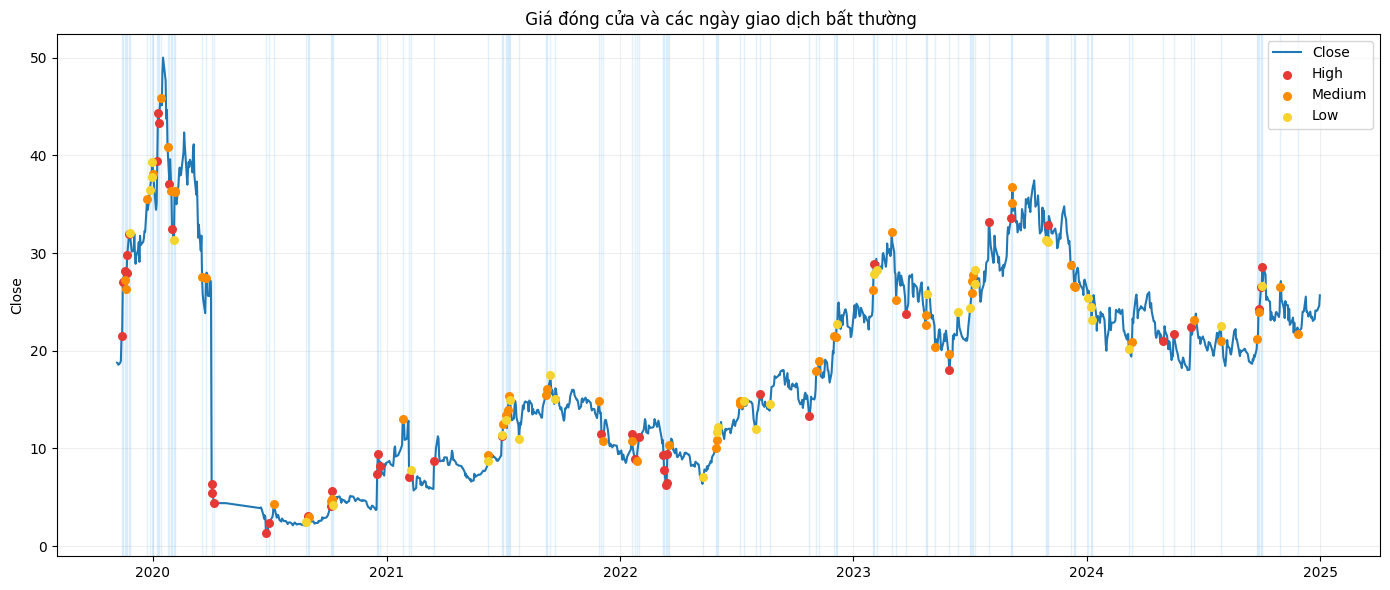

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============== Load data ==============
df = pd.read_csv("df_final_output.csv")
clu = pd.read_csv("clusters.csv") if True else pd.DataFrame()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Helpers
def severity_color(s):
    if s == 'High': return '#e53935'   # red
    if s == 'Medium': return '#fb8c00' # orange
    if s == 'Low': return '#f6d32d'    # yellow
    return '#9e9e9e'                   # grey for Normal

# ============== 1) Price + anomaly marks + cluster shading ==============
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(df['Date'], df['Close'], lw=1.5, label='Close')

# Shade clusters if available
if not clu.empty:
    clu['start_date'] = pd.to_datetime(clu['start_date'])
    clu['end_date']   = pd.to_datetime(clu['end_date'])
    for _, r in clu.iterrows():
        ax.axvspan(r['start_date'], r['end_date'], color='#90caf9', alpha=0.25)

# Mark anomalies by severity
for sev in ['High','Medium','Low']:
    m = (df['label']=='Yes') & (df['severity']==sev)
    ax.scatter(df.loc[m,'Date'], df.loc[m,'Close'], s=30, color=severity_color(sev), label=sev, zorder=3)

ax.set_title(' Giá đóng cửa và các ngày giao dịch bất thường')
ax.set_ylabel('Close')
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig('fig_price_anomalies.png', dpi=150)




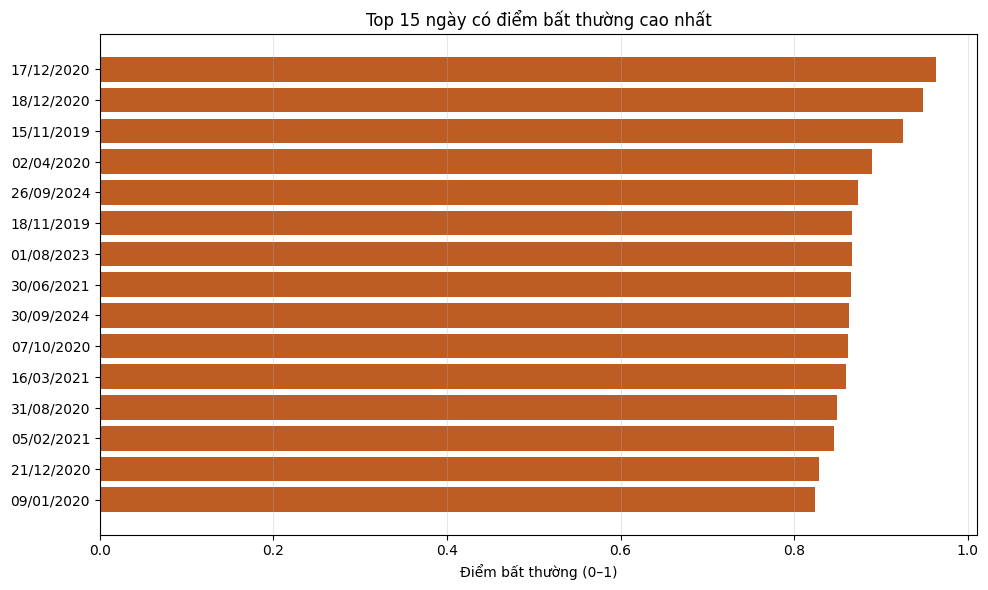

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============= Nạp dữ liệu =============
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Thử nạp file cụm
try:
    clu = pd.read_csv("clusters.csv")
    has_clusters = True
except FileNotFoundError:
    clu = pd.DataFrame()
    has_clusters = False


# ============= 3) Biểu đồ cột ngang: Top 15 ngày bất thường nhất =============
topn = (df.sort_values('anomaly_score', ascending=False)
          .head(15)
          .sort_values('anomaly_score'))
labels = topn['Date'].dt.strftime('%d/%m/%Y')

plt.figure(figsize=(10,6))
plt.barh(labels, topn['anomaly_score'].values, color="#bd5c23")
plt.title('Top 15 ngày có điểm bất thường cao nhất')
plt.xlabel('Điểm bất thường (0–1)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('bieudo_top15_ngay.png', dpi=150)
plt.show()



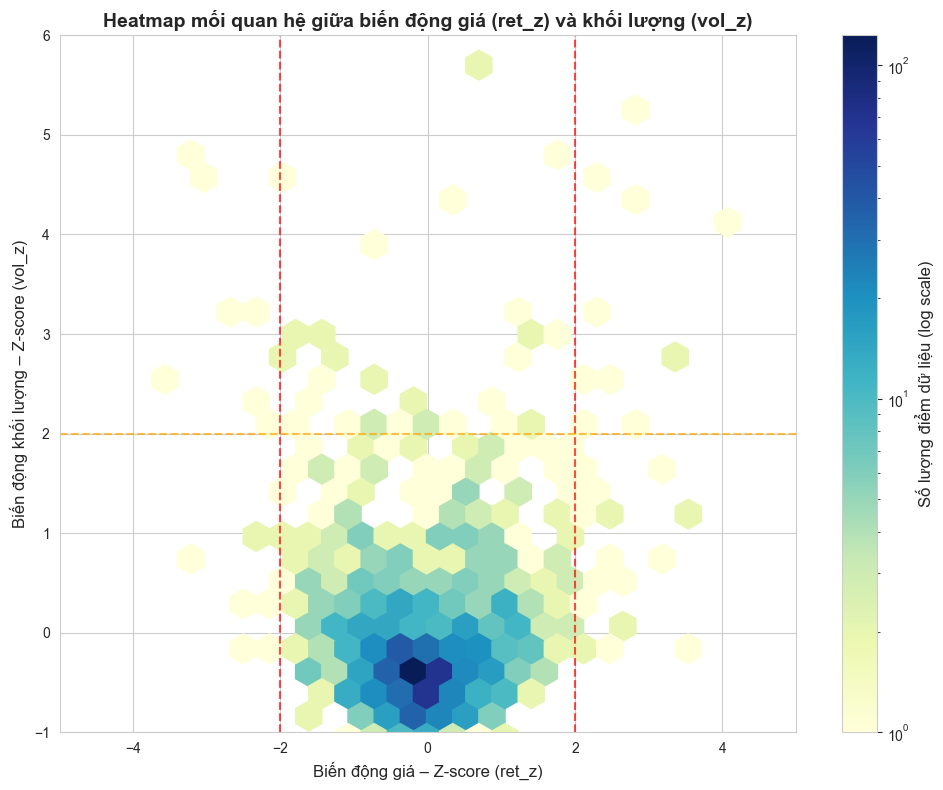

In [ ]:
plt.figure(figsize=(10,8))  # phóng to biểu đồ
sns.set_style("whitegrid")

hb = plt.hexbin(
    df['ret_z'], df['vol_z'],
    gridsize=45, cmap='YlGnBu', bins='log', mincnt=1
)

# Giới hạn trục để phóng vùng trung tâm rõ hơn
plt.xlim(-5, 5)
plt.ylim(-1, 6)

# Đường ngưỡng ±2σ
plt.axvline(x=2, color='red', linestyle='--', lw=1.5, alpha=0.7)
plt.axvline(x=-2, color='red', linestyle='--', lw=1.5, alpha=0.7)
plt.axhline(y=2, color='orange', linestyle='--', lw=1.5, alpha=0.7)

cb = plt.colorbar(hb)
cb.set_label('Số lượng điểm dữ liệu (log scale)', fontsize=12)

plt.title('Heatmap mối quan hệ giữa biến động giá (ret_z) và khối lượng (vol_z)', fontsize=14, fontweight='bold')
plt.xlabel('Biến động giá – Z-score (ret_z)', fontsize=12)
plt.ylabel('Biến động khối lượng – Z-score (vol_z)', fontsize=12)
plt.tight_layout()
plt.show()


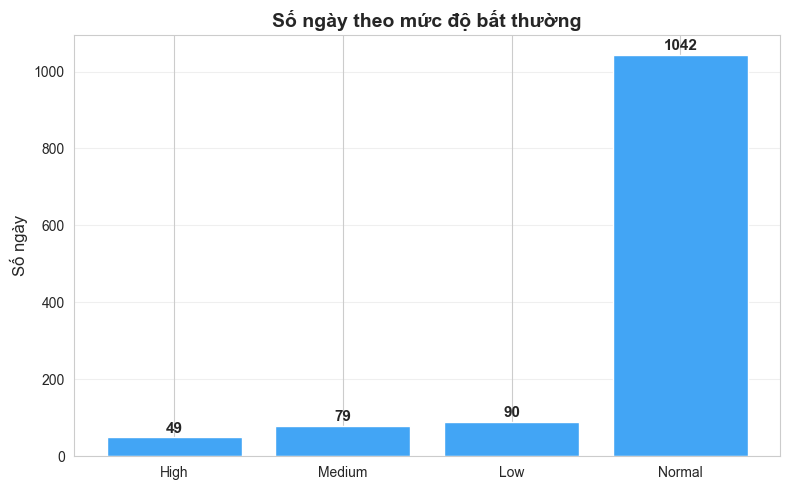

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Nạp dữ liệu
df = pd.read_csv("df_final_output.csv")

# Tính số lượng từng mức độ
severity_counts = df['severity'].value_counts().reindex(['High','Medium','Low','Normal'], fill_value=0)

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
bars = plt.bar(severity_counts.index, severity_counts.values, color='#42a5f5')

# Thêm nhãn số lên trên cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tiêu đề và nhãn trục
plt.title('Số ngày theo mức độ bất thường', fontsize=14, fontweight='bold')
plt.ylabel('Số ngày', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bieudo_muc_do_bat_thuong.png', dpi=150)
plt.show()


### OUTPUT

In [ ]:
#  --- 1. Nạp dữ liệu ---
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
total_days = len(df)

# --- 2. Thống kê cơ bản ---
abnormal_df = df[df['label'] == 'Yes']
n_abnormal = len(abnormal_df)
pct_abnormal = n_abnormal / total_days * 100
sev_counts = abnormal_df['severity'].value_counts().reindex(['High','Medium','Low'], fill_value=0)
high_n, med_n, low_n = sev_counts['High'], sev_counts['Medium'], sev_counts['Low']

# --- 3. Số chuỗi và độ dài chuỗi ---
df['group'] = (df['label'] != df['label'].shift()).cumsum()
yes_groups = df[df['label']=='Yes'].groupby('group')
n_clusters = yes_groups.ngroups
max_streak = yes_groups.size().max()

# --- 4. Sau đỉnh: đo dump và hồi (tính theo cụm) ---

clusters = pd.read_csv("clusters.csv")
clusters['post_3d_%'] = pd.to_numeric(clusters['post_3d_%'], errors='coerce')

post_mean = clusters.loc[clusters['post_5d_%'] > 0, 'post_5d_%'].mean()
crash_ratio = (clusters['post_3d_%'] <= -5).mean() * 100
recovery_ratio = (clusters['post_3d_%'] > 0).mean() * 100

# --- 5. Đánh giá tổng quan ---
avg_vol_z = df['vol_z'].mean()
avg_ret_std = df['return'].std()
long_term_vol = df['return'].rolling(120, min_periods=60).std().mean()

if avg_vol_z < 1.3 and avg_ret_std < 0.018 and long_term_vol < 0.02:
    conclusion = "Cổ phiếu ổn định - khó có khả năng thao túng."
    summary = "Các phiên bất thường xuất hiện ngắn và rải rác, giá hồi phục nhanh sau biến động."
elif high_n > 25 or pct_abnormal > 25 or crash_ratio > 30 or post_mean < -3 or (not np.isnan(recovery_ratio) and recovery_ratio < 35):
    conclusion = "Có dấu hiệu thao túng đáng kể."
    summary = "Nhiều giai đoạn biến động mạnh, giá giảm sâu và hồi phục yếu - đặc trưng của hành vi thao túng."
elif pct_abnormal > 15 or high_n > 15 or crash_ratio > 15:
    conclusion = "Có thể có thao túng, cần theo dõi thêm."
    summary = "Một vài giai đoạn dao động vượt chuẩn, nhưng chưa đủ kéo dài hay nghiêm trọng để kết luận thao túng."
else:
    conclusion = "Chưa phát hiện dấu hiệu thao túng rõ ràng."
    summary = "Dao động nằm trong phạm vi bình thường của thị trường, không có đợt giảm sâu đáng kể."
# --- 6. Diễn giải ---
if not np.isnan(recovery_ratio):
    if recovery_ratio < 25:
        recovery_comment = "Giá hầu như không hồi phục sau biến động."
    elif recovery_ratio < 45:
        recovery_comment = "Giá hồi phục hơi chậm nhưng ổn định sau biến động."
    elif recovery_ratio < 60:
        recovery_comment = "Giá hồi phục trung bình, dần lấy lại cân bằng sau biến động."
    else:
        recovery_comment = "Giá hồi phục nhanh sau biến động."

    summary = f"{summary.split(',')[0]}. {recovery_comment}"

# --- 7. Viết nhận định 
flag_suspicious = False
flag_manipulated = False

if not np.isnan(recovery_ratio):
    # mô tả hành vi giá
    if recovery_ratio < 25:
        recovery_text = "Giá hầu như không hồi phục sau các đợt biến động."
    elif recovery_ratio < 45:
        recovery_text = "Giá hồi phục chậm, thường không lấy lại được đà tăng ngay."
    elif recovery_ratio < 60:
        recovery_text = "Giá hồi phục trung bình, cần thời gian để ổn định trở lại."
    else:
        recovery_text = "Giá hồi phục khá nhanh, thường lấy lại cân bằng chỉ sau vài ngày."

    if crash_ratio < 10:
        crash_text = "Giá ít khi giảm sâu sau các đợt tăng."
    elif crash_ratio < 25:
        crash_text = "Thỉnh thoảng có sụt giảm nhẹ sau các đợt tăng."
    else:
        crash_text = "Thường xuyên xuất hiện các nhịp giảm mạnh trên 5%."

    # -- kiểm tra sức tăng ---
    if post_mean >= 0:
        if post_mean > 3:
            trend_text = f"Sau mỗi biến động, giá trung bình Tăng Mạnh khoảng {post_mean:.2f}%."
            flag_suspicious = True  # cảnh báo thao túng nhẹ
        elif post_mean > 0.3:
            trend_text = f"Sau mỗi biến động, giá trung bình Tăng Nhẹ khoảng {post_mean:.2f}%."
        else:
            trend_text = f"Sau mỗi biến động, giá gần như không biến động đáng kể ({post_mean:.2f}%)."
    else:
        trend_text = f"Sau mỗi biến động, giá trung bình giảm khoảng {abs(post_mean):.2f}%."

    # -- kiểm tra độ dài chuỗi ---
    if max_streak > 10:
        long = f" lên tới {int(max_streak)} ngày"
        flag_manipulated = True  # thao túng rõ ràng
    elif max_streak >= 7:
        long = f" khá cao : {int(max_streak)} ngày ==> đáng ngờ"
        flag_suspicious = True
    else:
        long = f" {int(max_streak)} ( các dịp lễ và sự kiện) --> dao động Ngắn, Bình Thường  "

    quant_summary = (
        f"\n- Qua quan sát khoảng {n_clusters} đợt biến động bất thường (mỗi đợt kéo dài trung bình{long})."
        f"\n- {trend_text}"
        f"\n- {crash_text}"
        f"\n- {recovery_text}"
    )
else:
    quant_summary = ""

summary = summary.rstrip(".") + "." + quant_summary

# --- 8. Kết luận 
if flag_manipulated:
    conclusion = "Cổ phiếu đã có dấu hiệu bị thao túng rõ ràng - cần đặc biệt cảnh giác."
elif flag_suspicious:
    conclusion = "Cẩn thận! Cổ phiếu này đang có dấu hiệu bị thao túng nhẹ (pump nhẹ hoặc kéo giá ngắn hạn)."
elif "ổn định" in conclusion and not np.isnan(recovery_ratio):
    if recovery_ratio < 45:
        conclusion = conclusion.replace("ổn định -", "ổn định, dù sức hồi phục chưa thật mạnh -")

# --- 9. In kết quả ---
print("TỔNG HỢP BẤT THƯỜNG:")
print(f"- Tổng số ngày bất thường: {n_abnormal}")
print(f"   • High  : {high_n} ngày")
print(f"   • Medium: {med_n} ngày")
print(f"   • Low   : {low_n} ngày")
print(f"- Tỷ lệ ngày bất thường: {pct_abnormal:.2f}%")
print(f"- Tỷ lệ hồi phục sau biến động: {recovery_ratio:.1f}%")

print("\nNHẬN ĐỊNH CHI TIẾT:")
for line in summary.split("\n"):
    if line.strip():
        print(line.strip())

print(f"\nKẾT LUẬN: {conclusion}")


TỔNG HỢP BẤT THƯỜNG:
- Tổng số ngày bất thường: 143
   • High  : 48 ngày
   • Medium: 58 ngày
   • Low   : 37 ngày
- Tỷ lệ ngày bất thường: 11.35%
- Tỷ lệ hồi phục sau biến động: 50.0%

NHẬN ĐỊNH CHI TIẾT:
Nhiều giai đoạn biến động mạnh. Giá hồi phục trung bình, dần lấy lại cân bằng sau biến động.
- Qua quan sát khoảng 74 đợt biến động bất thường (mỗi đợt kéo dài trung bình khá cao : 8 ngày ==> đáng ngờ).
- Sau mỗi biến động, giá trung bình Tăng Mạnh khoảng 16.52%.
- Thường xuyên xuất hiện các nhịp giảm mạnh trên 5%.
- Giá hồi phục trung bình, cần thời gian để ổn định trở lại.

KẾT LUẬN: Cẩn thận! Cổ phiếu này đang có dấu hiệu bị thao túng nhẹ (pump nhẹ hoặc kéo giá ngắn hạn).
